# Seaborn Relational plots

Two functions: `scatterplot` (points) and `lineplot` (connected points, usually for ordered data). Plus their figure-level wrapper `relplot`.



## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(0)

penguins = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")
fmri = sns.load_dataset("fmri")

## scatterplot — points in 2D

Recap from Notebook 1: pass a DataFrame and column names. `hue` colors by
a third variable.


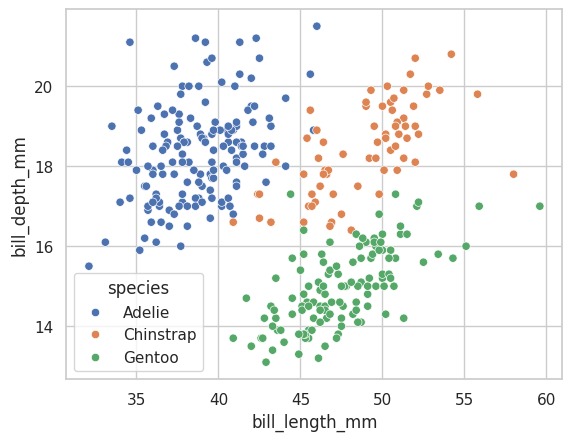

In [2]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm",
                hue="species")
plt.show()

## The encoding channels

Beyond `hue`, two more channels:

- `size` — point size varies by a variable. Works for both numeric and categorical.
- `style` — marker shape varies. Categorical only.

Using all three at once means a single plot can show 5 variables (x, y,
plus three encodings). This is a lot — readers can usually decode two
encodings easily, three at most. Use sparingly.


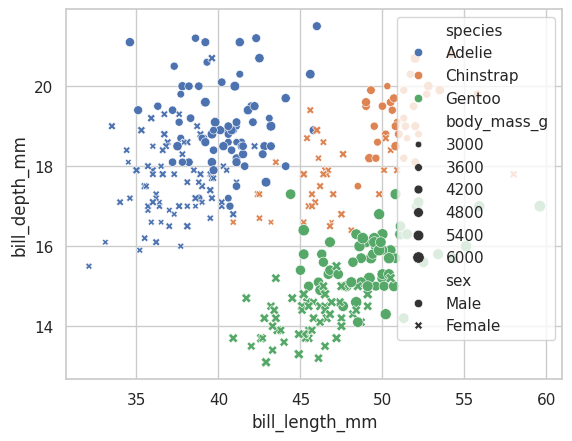

In [3]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",     # color
    size="body_mass_g", # size
    style="sex",        # marker shape
)
plt.show()

### size with a numeric variable

Seaborn maps the numeric range to point area. You can constrain the
range with `sizes=(min, max)`:


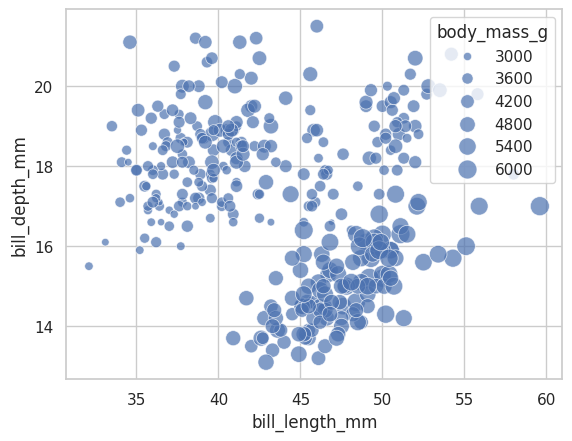

In [4]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    size="body_mass_g",
    sizes=(20, 200),    # min and max point area in points squared
    alpha=0.7,
)
plt.show()

`alpha` helps when points overlap. For dense scatter plots it can
prevent the plot from becoming a solid blob.


## Customizing the colors

When `hue` is categorical, seaborn picks colors from the active palette.
Override with `palette=`:


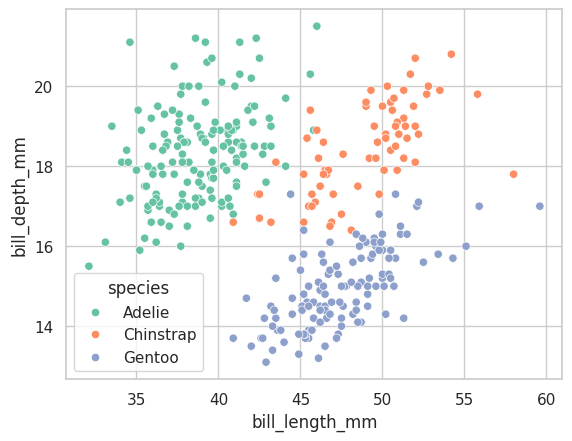

In [5]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette="Set2",     # qualitative palette suited for categorical data
)
plt.show()

When `hue` is numeric, seaborn uses a continuous palette (color
gradient). Same `palette=` argument, but pass a sequential palette name:


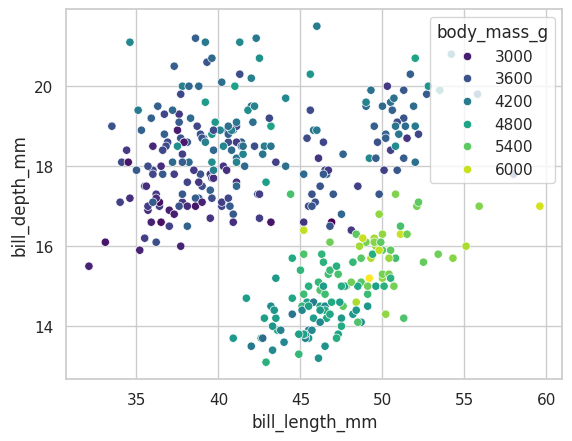

In [6]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="body_mass_g",
    palette="viridis",
)
plt.show()

Palette choice has a real impact on readability. Categorical data
should use a qualitative palette (`Set1`, `Set2`, `tab10`, etc.) so the
categories look equally distinct. Numeric data should use a sequential
palette (`viridis`, `magma`, `Blues`, etc.) so the visual ordering
matches the data ordering.


## lineplot — ordered data

`lineplot` connects points with lines. Use it when x has a natural
ordering, typically time.

The flights dataset has monthly passenger counts from 1949 to 1960:


In [7]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


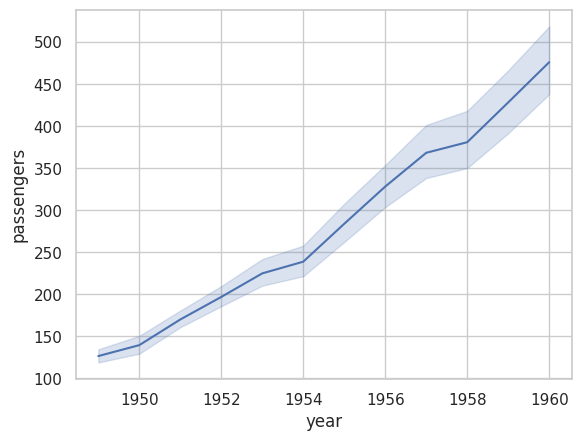

In [8]:
sns.lineplot(data=flights, x="year", y="passengers")
plt.show()

The dataset has 12 rows per year
(one per month) but the plot shows a single line with a shaded band.

Seaborn is **aggregating**. For each x value, it computes the mean and a
95% confidence interval, then plots both. The shaded band is the CI.

This is one of seaborn's most useful behaviors but it surprises people
who expect raw data.


### Showing aggregation explicitly

To disable the CI band:


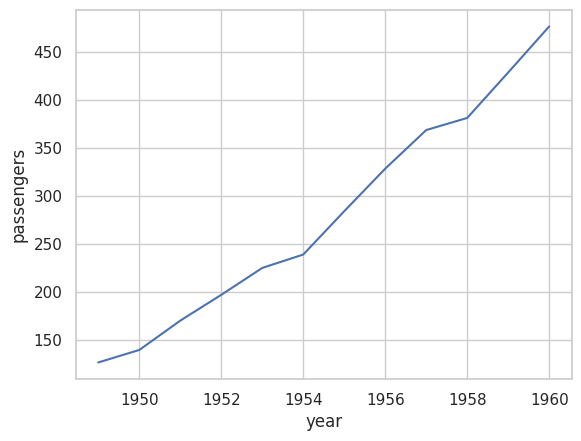

In [9]:
sns.lineplot(data=flights, x="year", y="passengers", errorbar=None)
plt.show()

To see the underlying months as separate lines, use `hue="month"`:


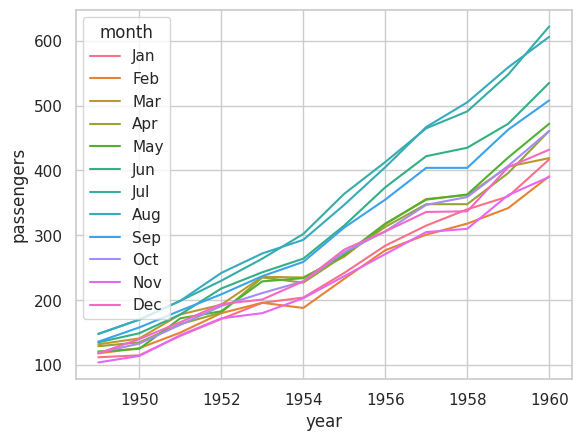

In [10]:
sns.lineplot(data=flights, x="year", y="passengers", hue="month")
plt.show()

Each month is its own line; no aggregation happens because each
x-value within a hue group has only one observation.


### Aggregation with multiple observations per x

The fmri dataset has multiple subjects per timepoint, so aggregation is
meaningful here.


In [11]:
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


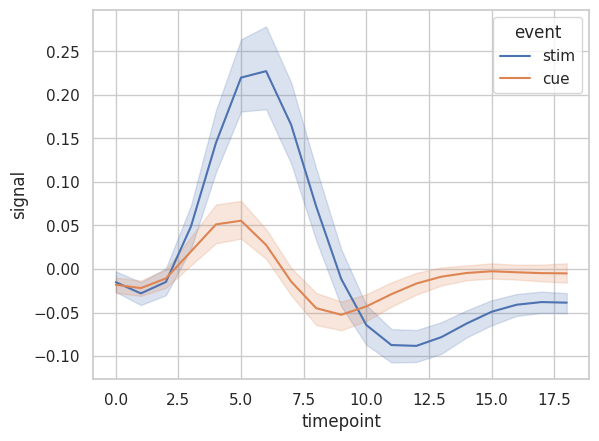

In [12]:
sns.lineplot(data=fmri, x="timepoint", y="signal", hue="event")
plt.show()

The bands show the variability across subjects at each timepoint.
This is the normal way to summarize repeated-measures data.

To change the error band — for example, to show ±1 standard deviation
instead of a confidence interval:


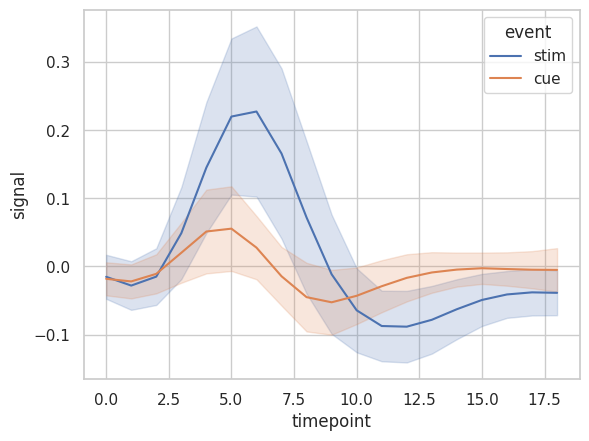

In [13]:
sns.lineplot(data=fmri, x="timepoint", y="signal", hue="event",
             errorbar="sd")  # could be 'ci', 'pi', 'se', 'sd', or None
plt.show()

## style for lineplot

`style` adds dashed/dotted variants in addition to color.


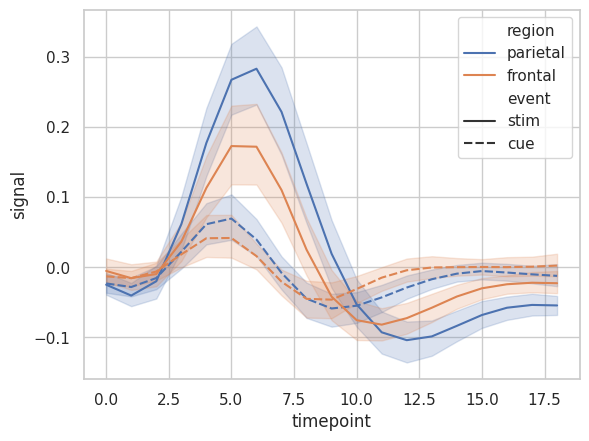

In [14]:
sns.lineplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="region",
    style="event",
)
plt.show()

Now color encodes region and dash pattern encodes event. Four
distinct lines from one call.


## relplot — figure-level relational

Figure-level wrapper. Lets you facet by `col` and `row`.


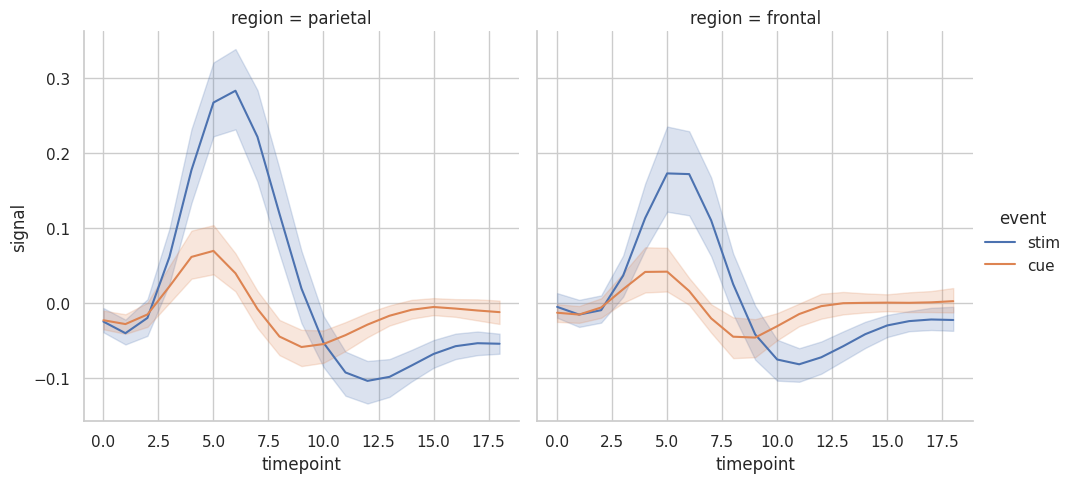

In [15]:
sns.relplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="event",
    col="region",
    kind="line",
)
plt.show()

`kind="line"` makes this equivalent to `lineplot`; `kind="scatter"`
(default) gives `scatterplot`.

Two facet dimensions:


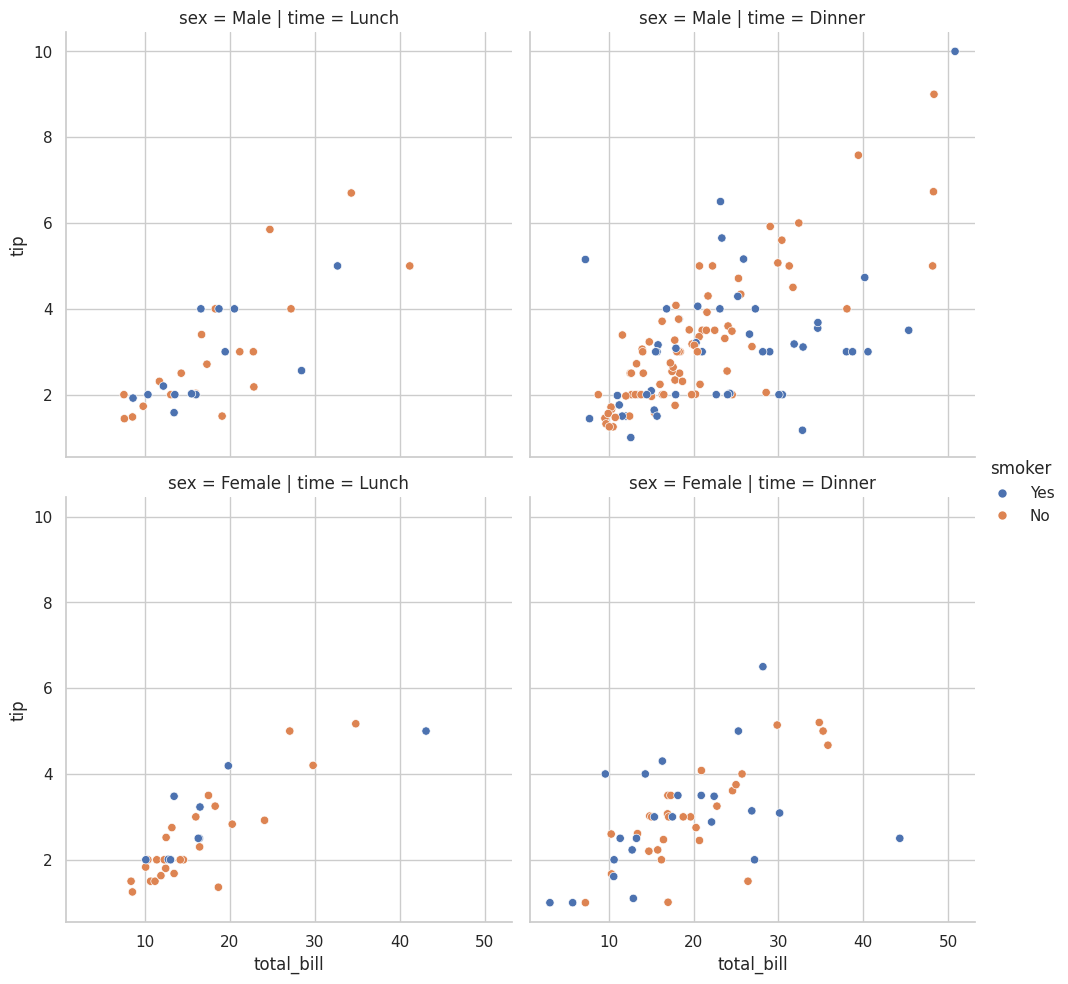

In [16]:
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    col="time",
    row="sex",
)
plt.show()

Four panels arranged in a 2×2 grid. Same plot logic, different
data subsets.

This is the kind of figure that would take 30 lines of Matplotlib
boilerplate. With `relplot`, it's one call.


## col_wrap — flat layout for many panels

When you have many categories and don't want a long horizontal strip,
`col_wrap` wraps panels onto multiple rows.


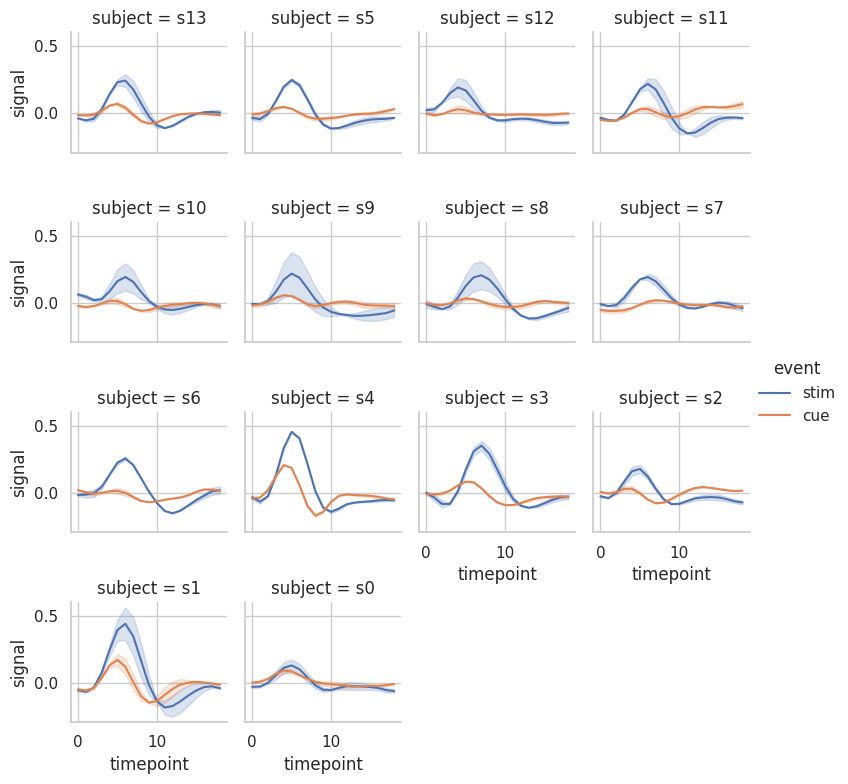

In [17]:
sns.relplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="event",
    col="subject",
    col_wrap=4,         # 4 panels per row
    kind="line",
    height=2,           # smaller panels since there are many
)
plt.show()

## Accessing the underlying axes

`relplot` returns a `FacetGrid` object, not a matplotlib axes. To
customize after the fact:


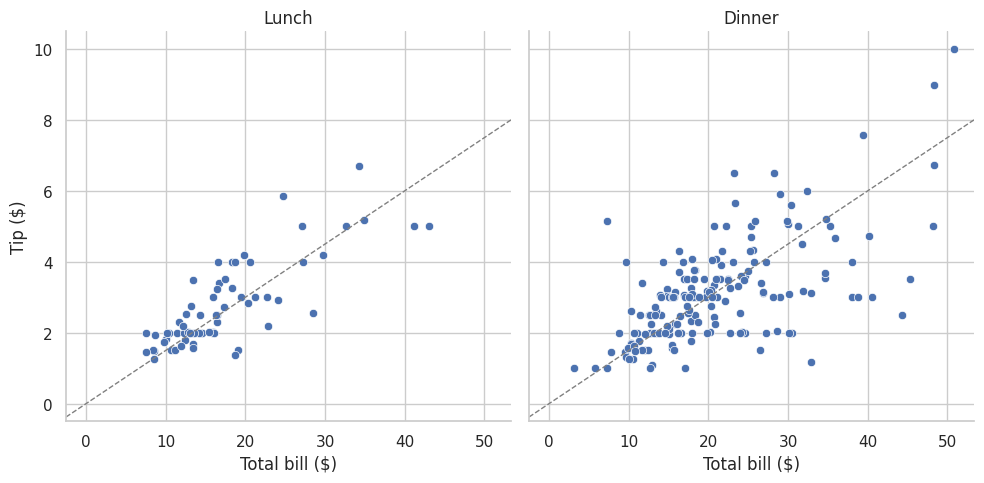

In [18]:
g = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="time",
    kind="scatter",
)

# Set a title for each panel
g.set_titles("{col_name}")

# Set common axis labels
g.set_axis_labels("Total bill ($)", "Tip ($)")

# Add a reference line to every panel
for ax in g.axes.flat:
    ax.axline((0, 0), slope=0.15, color="gray", linestyle="--", linewidth=1)

plt.show()

`g.axes.flat` iterates over all panels regardless of grid shape.
This is the standard way to apply per-panel customization.


**1. lineplot aggregates by default.** If your line looks wrong (smoother than expected, with a confidence band you didn't ask for), seaborn is averaging. Disable with `errorbar=None` or use `hue` to split into
separate lines.

**2. Numeric vs categorical hue produces different legends.** If your
"category" column is encoded as integers (1, 2, 3), seaborn treats it as numeric and gives a continuous color bar. Convert to string first:
`df["category"] = df["category"].astype(str)`.

**3. Size encoding is hard to read.** Most people cannot accurately
compare point sizes. If size is critical to the message, consider a
separate plot instead.

**4. relplot ignores `ax=`.** Like all figure-level functions. Use the returned `FacetGrid` to access axes.

**5. Order of legend matters.** For categorical hue, seaborn orders the legend by appearance order in the data. For consistent ordering across plots, set `hue_order=[...]`.
